In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import os
import pandas as pd

In [2]:
# Download absorption coefficients of Water

PATH_WATER = "Data_eau.csv"

water_df = pd.read_csv(PATH_WATER, header=None, names=["wavelength", "Water_abs"])
water_df["Water_abs_mm-1"] = (water_df["Water_abs"].values)/10

# target wavelength grid
wl_grid = np.arange(600, 1001, 2)   # 600, 602, 604, ..., 1000

# interpolate
water_interp = np.interp(wl_grid, water_df["wavelength"].values, water_df["Water_abs_mm-1"].values)

water_interp_df = pd.DataFrame({
    "wavelength": wl_grid,
    "Water_abs_mm-1": water_interp
})

wavelength_water = water_interp_df["wavelength"].values
mu_a_water = water_interp_df["Water_abs_mm-1"].values

print(water_interp_df)

     wavelength  Water_abs_mm-1
0           600        0.000190
1           602        0.000201
2           604        0.000212
3           606        0.000223
4           608        0.000234
..          ...             ...
196         992        0.035021
197         994        0.035351
198         996        0.035680
199         998        0.036010
200        1000        0.036339

[201 rows x 2 columns]


In [3]:
# Download extinction coefficients for HbO2 and Hb

df = pd.read_csv("hemoglobin_extinction_partial.csv")

x = 150  # g/L
df["mu_a_HbO2_mm-1"] = (2.303 * df["HbO2_cm-1_M"] * x / 64500)/10
df["mu_a_Hb_mm-1"]   = (2.303 * df["Hb_cm-1_M"]  * x / 64500)/10
df = df[df["lambda_nm"].between(600, 1000)]

wavelength = df["lambda_nm"].values
mu_a_HbO2 = df["mu_a_HbO2_mm-1"].values
mu_a_Hb = df["mu_a_Hb_mm-1"].values

print(df)

     lambda_nm  HbO2_cm-1_M  Hb_cm-1_M  mu_a_HbO2_mm-1  mu_a_Hb_mm-1
175      600.0       3200.0  14677.200        1.713860      7.860835
176      602.0       2664.0  13622.400        1.426789      7.295904
177      604.0       2128.0  12567.600        1.139717      6.730973
178      606.0       1789.2  11513.200        0.958262      6.166256
179      608.0       1647.6  10477.600        0.882424      5.611608
..         ...          ...        ...             ...           ...
371      992.0       1068.8    267.932        0.572429      0.143499
372      994.0       1057.6    252.648        0.566431      0.135314
373      996.0       1046.4    237.360        0.560432      0.127126
374      998.0       1035.2    222.072        0.554434      0.118938
375     1000.0       1024.0    206.784        0.548435      0.110750

[201 rows x 5 columns]


In [4]:
# Create original mesh

# --- 1. Define mesh grid ---
x_max = 10
x_step = 0.1
x = np.arange(0, x_max + x_step, x_step)

layer_thickness = [0.02, 0.25, 0.10, 0.08, 0.20, 0.30]
z_max = sum(layer_thickness)
z_step = 0.001
z = np.arange(0, z_max, z_step)

X, Z = np.meshgrid(x, z)

# --- 2. Initialize property arrays ---
n = np.zeros_like(X)
mu_s = np.zeros_like(X)

# 3D absorption array
mu_a = np.zeros((len(wavelength), *X.shape))

# --- 3. Assign refractive index and scattering ---
layer_edges = np.cumsum(layer_thickness)

mask = Z < layer_edges[1]
n[mask] = 1.42
mu_s[mask] = 20.1

mask = Z >= layer_edges[1]
n[mask] = 1.39
mu_s[mask] = 20.1


# --- Layer masks ---
stratum = Z < layer_edges[0]
epiderme = (Z >= layer_edges[0]) & (Z < layer_edges[1])
papille_dermique = (Z >= layer_edges[1]) & (Z < layer_edges[2])
derme_supérieur = (Z >= layer_edges[2]) & (Z < layer_edges[3])
derme_réticulaire = (Z >= layer_edges[3]) & (Z < layer_edges[4])
derme_profond = (Z >= layer_edges[4]) & (Z <= layer_edges[5])


# --- Precompute wavelength dependent spectra ---
mu_a_mel = 6.6e10 * (wavelength ** -3.33)
mu_a_baseline = 7.84e7 * (wavelength ** -3.255)

V_mel = 0.1


for i, wn in enumerate(wavelength):

    mu_mel = mu_a_mel[i]
    mu_baseline = mu_a_baseline[i]
    mu_water = mu_a_water[i]

    # --- Stratum corneum ---
    V_water_stratum = 0.05
    mu_stratum = (
        V_mel * mu_mel +
        V_water_stratum * mu_water +
        (1 - (V_mel + V_water_stratum)) * mu_baseline
    )

    mu_a[i][stratum] = mu_stratum


    # --- Epidermis ---
    V_water_epiderme = 0.2
    mu_epiderme = (
        V_mel * mu_mel +
        V_water_epiderme * mu_water +
        (1 - (V_mel + V_water_epiderme)) * mu_baseline
    )

    mu_a[i][epiderme] = mu_epiderme


    # --- Hemoglobin absorption ---
    mu_Hb = mu_a_Hb[i]
    mu_HbO2 = mu_a_HbO2[i]

    SaO2 = 0.98
    SvO2 = SaO2 - 0.1

    mu_A = SaO2 * mu_HbO2 + (1 - SaO2) * mu_Hb
    mu_V = SvO2 * mu_HbO2 + (1 - SvO2) * mu_Hb


    # --- Papillary dermis ---
    Vb = 0.04
    Vw = 0.5

    mu_val = (
        0.5 * Vb * (mu_A + mu_V)
        + Vw * mu_water
        + (1 - (Vb + Vw)) * mu_baseline
    )

    mu_a[i][papille_dermique] = mu_val


    # --- Upper dermis ---
    Vb = 0.3
    Vw = 0.6

    mu_val = (
        0.5 * Vb * (mu_A + mu_V)
        + Vw * mu_water
        + (1 - (Vb + Vw)) * mu_baseline
    )

    mu_a[i][derme_supérieur] = mu_val


    # --- Reticular dermis ---
    Vb = 0.04
    Vw = 0.7

    mu_val = (
        0.5 * Vb * (mu_A + mu_V)
        + Vw * mu_water
        + (1 - (Vb + Vw)) * mu_baseline
    )

    mu_a[i][derme_réticulaire] = mu_val


    # --- Deep dermis ---
    Vb = 0.1
    Vw = 0.7

    mu_val = (
        0.5 * Vb * (mu_A + mu_V)
        + Vw * mu_water
        + (1 - (Vb + Vw)) * mu_baseline
    )

    mu_a[i][derme_profond] = mu_val

print(mu_a.shape)

(201, 950, 101)


In [6]:
import numpy as np

def simulate_light_propagation(mu_abs, mu_s, n):
    g = 0.9
    Wc = 0.01
    m = 10
    Nz, Nx = mu_abs.shape
    N_photons = 5000

    rng = np.random.default_rng()

    # initialize absorption map
    A = np.zeros_like(mu_abs)

    # compute max coordinates
    x_max = Nx * x_step
    z_max = Nz * z_step

    for p in range(N_photons):
        W = 1.0
        mu_x = 0
        mu_z = 1
        x = x_max / 2
        z = 0

        while True:
            # convert to voxel indices
            ix = int(x / x_step)
            iz = int(z / z_step)

            # stop photon if outside medium
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # total interaction coefficient at current voxel
            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                print("Shit")
                break  # stop photon if no scattering/absorption

            # mean free path
            s = -np.log(rng.uniform()) / mu_t

            # --- Fresnel reflection/transmission ---
            next_z = z + mu_z * s
            next_iz = int(next_z / z_step)
            if 0 <= next_iz < Nz:
                n1 = n[iz, ix]
                n2 = n[next_iz, ix]
                if n1 != n2:  # interface detected
                    theta_i = np.arccos(abs(mu_z))  # angle with normal
                    sin_theta_t = n1 / n2 * np.sin(theta_i)
                    if sin_theta_t > 1:  # total internal reflection
                        mu_z = -mu_z
                    else:
                        theta_t = np.arcsin(sin_theta_t)
                        cos_theta_i = np.cos(theta_i)
                        cos_theta_t = np.cos(theta_t)
                        Rs = ((n1 * cos_theta_i - n2 * cos_theta_t) / 
                              (n1 * cos_theta_i + n2 * cos_theta_t))**2
                        Rp = ((n1 * cos_theta_t - n2 * cos_theta_i) / 
                              (n1 * cos_theta_t + n2 * cos_theta_i))**2
                        R = 0.5 * (Rs + Rp)
                        if rng.uniform() < R:
                            mu_z = -mu_z  # reflect
                        else:
                            mu_z = np.sign(mu_z) * cos_theta_t  # transmit
                            # adjust horizontal component to conserve direction magnitude
                            if np.sin(theta_i) < 1e-12:  # photon moving almost perfectly vertical
                                # horizontal component stays the same
                                mu_x = mu_x
                            else:
                                mu_x = mu_x * np.sin(theta_t) / np.sin(theta_i)

            # propagate photon
            x += mu_x * s
            z += mu_z * s

            # convert new positions to voxel indices
            ix = int(x / x_step)
            iz = int(z / z_step)

            # stop if outside
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # recalc total interaction coefficient at new voxel
            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]

            # absorption
            deltaW = (mu_abs[iz, ix]/mu_t) * W
            W -= deltaW
            A[iz, ix] += deltaW

            # Russian roulette
            if W < Wc:
                if rng.uniform() <= 1/m:
                    W *= m
                else:
                    break

            # Diffusion (2D Henyey-Greenstein)
            e2 = rng.uniform()
            e3 = rng.uniform()
            phi = 2 * np.pi * e2
            cos_theta = (1/(2*g))*(1 + g**2 - ((1-g**2)/(1-g + 2*g*e3))**2)
            sin_theta = np.sqrt(1 - cos_theta**2)
            mu_x_new = sin_theta * np.cos(phi)
            mu_z_new = np.sign(mu_z) * cos_theta
            mu_x, mu_z = mu_x_new, mu_z_new

    A /= N_photons
    return A

In [7]:
import numpy as np
import matplotlib.pyplot as plt

X_PERCENT = 0.9  # 90% of absorbed energy
max_depths = []

for i, wl in enumerate(wavelength):
    print(wl)
    mu_a_current = mu_a[i]  # absorption map (Nz, Nx)
    print(mu_a_current.max())
    A = simulate_light_propagation(mu_a_current, mu_s, n)  # returns (Nz, Nx)

    # sum absorption along x to get total absorbed energy per z
    absorption_per_z = A.sum(axis=1)  # shape (Nz,)

    # cumulative absorption from surface to depth
    cumulative = np.cumsum(absorption_per_z)

    # normalize to fraction of total absorbed energy
    cumulative_frac = cumulative / cumulative[-1]

    # find the first depth where cumulative fraction >= X_PERCENT
    iz_90 = np.searchsorted(cumulative_frac, X_PERCENT)

    depth_90 = iz_90 * z_step  # convert index to physical depth
    max_depths.append(depth_90)

# plot
plt.figure(figsize=(6,4))
plt.plot(wavelength, max_depths, '-o')
plt.xlabel("Wavelength (nm)")
plt.ylabel(f"Depth at {int(X_PERCENT*100)}% cumulative absorption (mm)")
plt.title("Effective penetration depth per wavelength")
plt.grid(True)
plt.show()

600.0
3.761223544349355
602.0
3.71978904027385
604.0
3.678946172148853
606.0
3.6386845748812626
608.0
3.5989940983381343
610.0
3.5598648022011217
612.0
3.521286689007962
614.0
3.4832504060169502
616.0
3.445746691976586
618.0
3.4087663970992077
620.0
3.3723005576943663
622.0
3.3363403917997974
624.0
3.300877294928571
626.0
3.2659028359289906
628.0
3.2314087529539037
630.0
3.197386949536193
632.0
3.1638294907673243
634.0
3.130728599575924
636.0
3.098076653103484
638.0
3.065866179174331
640.0
3.034089852857151
642.0
3.0027404931154047
644.0
2.9718110595440668
646.0
2.941294649190211
648.0
2.9111844934550306
650.0
2.88147395507497
652.0
2.852156525179703
654.0
2.8232258204247858
656.0
2.7946755801968544
658.0
2.766499828966829
660.0
2.7386924815707996
662.0
2.711247526345839
664.0
2.684159167035534
666.0
2.657421717159276
668.0
2.6310295976118896
670.0
2.604977334322726
672.0
2.579259555972586
674.0
2.553870991766875
676.0
2.5288064692634356
678.0
2.5040609122535713
680.0
2.479629338694797

KeyboardInterrupt: 

# EXPLORATION

wavelength = 660 nm
angle = 80 deg
N_photons = 50000
refine_factor = 10
x_step_refined = 0.01
z_step = 0.001
x_step_refined / z_step = 10.0


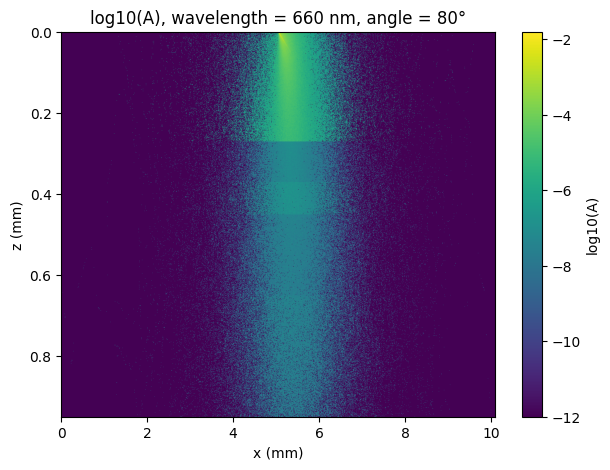

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Helper: refine x-grid to reduce blocky staircase artifacts
# =========================================================
def refine_x_grid(field_2d, refine_factor=10):
    return np.repeat(field_2d, refine_factor, axis=1)


# =========================================================
# Main simulation
# Keeps the original lab structure as much as possible
# Added features:
#   - launch angle theta0_deg
#   - relative 2D scattering
#   - optional debug printing
#   - local x_step so we do not break the notebook globals
# =========================================================
def simulate_light_propagation(
    mu_abs,
    mu_s,
    n,
    x_step_local,
    z_step_local,
    theta0_deg=0.0,
    N_photons=5000,
    debug=False,
    max_debug_prints=30,
):
    g = 0.9
    Wc = 0.01
    m = 10

    Nz, Nx = mu_abs.shape
    rng = np.random.default_rng()

    # initialize absorption map
    A = np.zeros_like(mu_abs, dtype=float)

    # compute max coordinates
    x_max_local = Nx * x_step_local
    z_max_local = Nz * z_step_local

    # initial angle measured from +z axis
    # 0°  = straight down
    # +θ  = tilted toward +x
    # -θ  = tilted toward -x
    theta0 = np.deg2rad(theta0_deg)

    debug_count = 0

    for p in range(N_photons):
        W = 1.0

        # initial launch direction
        mu_x = np.sin(theta0)
        mu_z = np.cos(theta0)

        x = x_max_local / 2.0
        z = 0.0

        while True:
            # current voxel
            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            # stop photon if outside medium
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # total interaction coefficient
            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                break

            # mean free path
            s = -np.log(rng.uniform()) / mu_t

            # default: no interface crossed this step
            R = np.nan

            # -----------------------------------------
            # Fresnel reflection / transmission in z
            # -----------------------------------------
            next_z = z + mu_z * s
            next_iz = int(next_z / z_step_local)

            if 0 <= next_iz < Nz:
                n1 = n[iz, ix]
                n2 = n[next_iz, ix]

                if n1 != n2:
                    theta_i = np.arccos(np.clip(abs(mu_z), 0.0, 1.0))
                    sin_theta_t = (n1 / n2) * np.sin(theta_i)

                    if sin_theta_t > 1.0:
                        # total internal reflection
                        mu_z = -mu_z
                        R = 1.0
                    else:
                        theta_t = np.arcsin(sin_theta_t)

                        cos_theta_i = np.cos(theta_i)
                        cos_theta_t = np.cos(theta_t)

                        Rs = ((n1 * cos_theta_i - n2 * cos_theta_t) /
                              (n1 * cos_theta_i + n2 * cos_theta_t))**2
                        Rp = ((n1 * cos_theta_t - n2 * cos_theta_i) /
                              (n1 * cos_theta_t + n2 * cos_theta_i))**2
                        R = 0.5 * (Rs + Rp)

                        if rng.uniform() < R:
                            # reflect
                            mu_z = -mu_z
                        else:
                            # transmit
                            mu_z = np.sign(mu_z) * cos_theta_t

                            # adjust horizontal component
                            if np.sin(theta_i) >= 1e-12:
                                mu_x = mu_x * np.sin(theta_t) / np.sin(theta_i)

                            # normalize after transmission
                            norm = np.sqrt(mu_x**2 + mu_z**2)
                            if norm > 0:
                                mu_x /= norm
                                mu_z /= norm

            # propagate photon
            x += mu_x * s
            z += mu_z * s

            # new voxel
            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            # stop if outside
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # recalc total interaction coefficient
            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                break

            # absorption
            deltaW = (mu_abs[iz, ix] / mu_t) * W
            W -= deltaW
            A[iz, ix] += deltaW

            # optional debug
            if debug and debug_count < max_debug_prints:
                print(
                    f"photon={p}, ix={ix}, iz={iz}, "
                    f"mu_x={mu_x:.6f}, mu_z={mu_z:.6f}, R={R}"
                )
                debug_count += 1

            # Russian roulette
            if W < Wc:
                if rng.uniform() <= 1 / m:
                    W *= m
                else:
                    break

            # -----------------------------------------
            # 2D scattering relative to current direction
            # -----------------------------------------
            e3 = rng.uniform()

            cos_delta = (1 / (2 * g)) * (
                1 + g**2 - ((1 - g**2) / (1 - g + 2 * g * e3))**2
            )
            cos_delta = np.clip(cos_delta, -1.0, 1.0)

            delta = np.arccos(cos_delta)

            # random left/right deflection in 2D
            if rng.uniform() < 0.5:
                delta = -delta

            mu_x_new = mu_x * np.cos(delta) + mu_z * np.sin(delta)
            mu_z_new = -mu_x * np.sin(delta) + mu_z * np.cos(delta)

            norm = np.sqrt(mu_x_new**2 + mu_z_new**2)
            if norm > 0:
                mu_x = mu_x_new / norm
                mu_z = mu_z_new / norm
            else:
                break

    A /= N_photons
    return A


# =========================================================
# Convenience runner + plotter
# Assumes wavelength, mu_a, mu_s, n, x_step, z_step already exist
# from your notebook above
# =========================================================
def run_angle_simulation(
    wl_test=660,
    theta_test=20,
    N_test=50000,
    refine_factor=10,
    debug=False,
    max_debug_prints=30,
):
    # pick wavelength index from existing notebook variable
    i_test = np.where(wavelength == wl_test)[0][0]

    # refine x-grid only
    mu_a_refined = refine_x_grid(mu_a[i_test], refine_factor=refine_factor)
    mu_s_refined = refine_x_grid(mu_s, refine_factor=refine_factor)
    n_refined = refine_x_grid(n, refine_factor=refine_factor)

    # local refined x step
    x_step_refined = x_step / refine_factor
    z_step_local = z_step

    print(f"wavelength = {wl_test} nm")
    print(f"angle = {theta_test} deg")
    print(f"N_photons = {N_test}")
    print(f"refine_factor = {refine_factor}")
    print(f"x_step_refined = {x_step_refined}")
    print(f"z_step = {z_step_local}")
    print(f"x_step_refined / z_step = {x_step_refined / z_step_local}")

    A_test = simulate_light_propagation(
        mu_abs=mu_a_refined,
        mu_s=mu_s_refined,
        n=n_refined,
        x_step_local=x_step_refined,
        z_step_local=z_step_local,
        theta0_deg=theta_test,
        N_photons=N_test,
        debug=debug,
        max_debug_prints=max_debug_prints,
    )

    x_max_plot = mu_a_refined.shape[1] * x_step_refined
    z_max_plot = mu_a_refined.shape[0] * z_step_local

    plt.figure(figsize=(7, 5))
    plt.imshow(
        np.log10(A_test + 1e-12),
        extent=[0, x_max_plot, z_max_plot, 0],
        aspect='auto',
        cmap='viridis'
    )
    plt.xlabel("x (mm)")
    plt.ylabel("z (mm)")
    plt.title(f"log10(A), wavelength = {wl_test} nm, angle = {theta_test}°")
    plt.colorbar(label="log10(A)")
    plt.show()

    return A_test, x_step_refined, z_step_local


# =========================================================
# EXAMPLE RUN
# Change only these 4 values
# =========================================================
A_test, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=660,
    theta_test=80,
    N_test=50000,
    refine_factor=10,
    debug=False
)

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Helper: refine x-grid to reduce blocky staircase artifacts
# ---------------------------------------------------------
def refine_x_grid(field_2d, refine_factor=10):
    return np.repeat(field_2d, refine_factor, axis=1)


# ---------------------------------------------------------
# Diagnostic simulation:
# can force reflection, or keep only reflected photons
# ---------------------------------------------------------
def simulate_light_propagation_reflection_diagnostic(
    mu_abs,
    mu_s,
    n,
    x_step_local,
    z_step_local,
    theta0_deg=0.0,
    N_photons=5000,
    force_reflection=False,          # if True, every interface hit reflects
    reflected_only=False,            # if True, only photons that reflected contribute
    stop_after_first_reflection=False, # if True, stop photon right after first reflection
    debug=False,
    max_debug_prints=30,
):
    g = 0.9
    Wc = 0.01
    m = 10

    Nz, Nx = mu_abs.shape
    rng = np.random.default_rng()

    A = np.zeros_like(mu_abs, dtype=float)

    x_max_local = Nx * x_step_local
    z_max_local = Nz * z_step_local

    theta0 = np.deg2rad(theta0_deg)

    debug_count = 0
    total_interface_hits = 0
    total_reflections = 0
    total_reflected_photons = 0

    for p in range(N_photons):
        W = 1.0
        mu_x = np.sin(theta0)
        mu_z = np.cos(theta0)

        x = x_max_local / 2.0
        z = 0.0

        photon_reflected = False

        while True:
            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                break

            s = -np.log(rng.uniform()) / mu_t
            R = np.nan

            # -----------------------------
            # Fresnel / forced reflection
            # -----------------------------
            next_z = z + mu_z * s
            next_iz = int(next_z / z_step_local)

            if 0 <= next_iz < Nz:
                n1 = n[iz, ix]
                n2 = n[next_iz, ix]

                if n1 != n2:
                    total_interface_hits += 1

                    theta_i = np.arccos(np.clip(abs(mu_z), 0.0, 1.0))
                    sin_theta_t = (n1 / n2) * np.sin(theta_i)

                    if force_reflection:
                        R = 1.0
                        mu_z = -mu_z
                        photon_reflected = True
                        total_reflections += 1

                        if debug and debug_count < max_debug_prints:
                            print(f"[FORCED REFLECTION] photon={p}, ix={ix}, iz={iz}, "
                                  f"mu_x={mu_x:.6f}, mu_z={mu_z:.6f}")
                            debug_count += 1

                    else:
                        if sin_theta_t > 1.0:
                            # total internal reflection
                            R = 1.0
                            mu_z = -mu_z
                            photon_reflected = True
                            total_reflections += 1

                            if debug and debug_count < max_debug_prints:
                                print(f"[TIR] photon={p}, ix={ix}, iz={iz}, "
                                      f"mu_x={mu_x:.6f}, mu_z={mu_z:.6f}")
                                debug_count += 1
                        else:
                            theta_t = np.arcsin(sin_theta_t)
                            cos_theta_i = np.cos(theta_i)
                            cos_theta_t = np.cos(theta_t)

                            Rs = ((n1 * cos_theta_i - n2 * cos_theta_t) /
                                  (n1 * cos_theta_i + n2 * cos_theta_t))**2
                            Rp = ((n1 * cos_theta_t - n2 * cos_theta_i) /
                                  (n1 * cos_theta_t + n2 * cos_theta_i))**2
                            R = 0.5 * (Rs + Rp)

                            if rng.uniform() < R:
                                mu_z = -mu_z
                                photon_reflected = True
                                total_reflections += 1

                                if debug and debug_count < max_debug_prints:
                                    print(f"[REAL REFLECTION] photon={p}, ix={ix}, iz={iz}, "
                                          f"R={R:.6f}, mu_x={mu_x:.6f}, mu_z={mu_z:.6f}")
                                    debug_count += 1
                            else:
                                mu_z = np.sign(mu_z) * cos_theta_t

                                if np.sin(theta_i) >= 1e-12:
                                    mu_x = mu_x * np.sin(theta_t) / np.sin(theta_i)

                                norm = np.sqrt(mu_x**2 + mu_z**2)
                                if norm > 0:
                                    mu_x /= norm
                                    mu_z /= norm

            # propagate
            x += mu_x * s
            z += mu_z * s

            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                break

            # absorb
            deltaW = (mu_abs[iz, ix] / mu_t) * W
            W -= deltaW

            # accumulate only if:
            #  - normal mode: all photons contribute
            #  - reflected_only mode: only photons that have reflected at least once contribute
            if (not reflected_only) or photon_reflected:
                A[iz, ix] += deltaW

            if photon_reflected and stop_after_first_reflection:
                break

            # Russian roulette
            if W < Wc:
                if rng.uniform() <= 1 / m:
                    W *= m
                else:
                    break

            # 2D scattering relative to current direction
            e3 = rng.uniform()

            cos_delta = (1 / (2 * g)) * (
                1 + g**2 - ((1 - g**2) / (1 - g + 2 * g * e3))**2
            )
            cos_delta = np.clip(cos_delta, -1.0, 1.0)

            delta = np.arccos(cos_delta)
            if rng.uniform() < 0.5:
                delta = -delta

            mu_x_new = mu_x * np.cos(delta) + mu_z * np.sin(delta)
            mu_z_new = -mu_x * np.sin(delta) + mu_z * np.cos(delta)

            norm = np.sqrt(mu_x_new**2 + mu_z_new**2)
            if norm > 0:
                mu_x = mu_x_new / norm
                mu_z = mu_z_new / norm
            else:
                break

        if photon_reflected:
            total_reflected_photons += 1

    A /= N_photons

    stats = {
        "total_interface_hits": total_interface_hits,
        "total_reflections": total_reflections,
        "total_reflected_photons": total_reflected_photons,
        "fraction_reflected_photons": total_reflected_photons / N_photons
    }

    return A, stats


# ---------------------------------------------------------
# Runner
# ---------------------------------------------------------
def run_reflection_diagnostic(
    wl_test=660,
    theta_test=80,
    N_test=200000,
    refine_factor=10,
    force_reflection=False,
    reflected_only=False,
    stop_after_first_reflection=False,
    debug=False,
):
    i_test = np.where(wavelength == wl_test)[0][0]

    mu_a_refined = refine_x_grid(mu_a[i_test], refine_factor=refine_factor)
    mu_s_refined = refine_x_grid(mu_s, refine_factor=refine_factor)
    n_refined    = refine_x_grid(n, refine_factor=refine_factor)

    x_step_refined = x_step / refine_factor
    z_step_local = z_step

    A_test, stats = simulate_light_propagation_reflection_diagnostic(
        mu_abs=mu_a_refined,
        mu_s=mu_s_refined,
        n=n_refined,
        x_step_local=x_step_refined,
        z_step_local=z_step_local,
        theta0_deg=theta_test,
        N_photons=N_test,
        force_reflection=force_reflection,
        reflected_only=reflected_only,
        stop_after_first_reflection=stop_after_first_reflection,
        debug=debug,
        max_debug_prints=60,
    )

    x_max_plot = mu_a_refined.shape[1] * x_step_refined
    z_max_plot = mu_a_refined.shape[0] * z_step_local

    plt.figure(figsize=(7, 5))
    plt.imshow(
        np.log10(A_test + 1e-12),
        extent=[0, x_max_plot, z_max_plot, 0],
        aspect='auto',
        cmap='viridis'
    )
    plt.xlabel("x (mm)")
    plt.ylabel("z (mm)")

    mode = []
    if force_reflection:
        mode.append("forced reflection")
    else:
        mode.append("real Fresnel")
    if reflected_only:
        mode.append("reflected photons only")
    if stop_after_first_reflection:
        mode.append("stop after first reflection")

    plt.title(
        f"log10(A), {wl_test} nm, angle = {theta_test}°\n" + ", ".join(mode)
    )
    plt.colorbar(label="log10(A)")
    plt.show()

    print("Stats:")
    for k, v in stats.items():
        print(f"  {k}: {v}")

    return A_test, stats

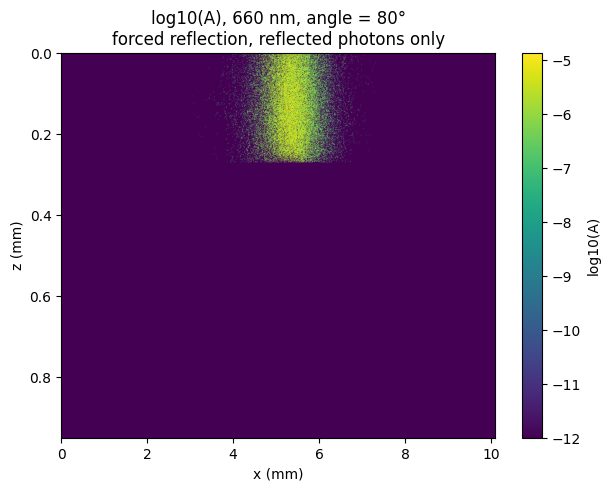

Stats:
  total_interface_hits: 9030
  total_reflections: 9030
  total_reflected_photons: 7348
  fraction_reflected_photons: 0.3674


In [12]:
A_forced, stats_forced = run_reflection_diagnostic(
    wl_test=660,
    theta_test=80,
    N_test=20000,
    refine_factor=10,
    force_reflection=True,
    reflected_only=True,
    stop_after_first_reflection=False,
    debug=False,
)

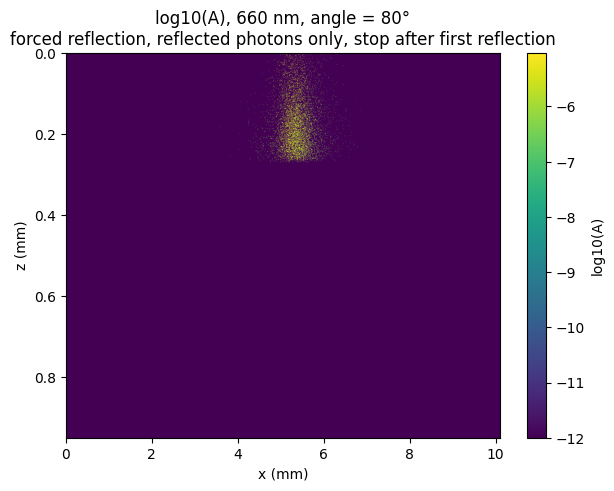

Stats:
  total_interface_hits: 7305
  total_reflections: 7305
  total_reflected_photons: 7305
  fraction_reflected_photons: 0.36525


In [13]:
A_forced_stop, stats_forced_stop = run_reflection_diagnostic(
    wl_test=660,
    theta_test=80,
    N_test=20000,
    refine_factor=10,
    force_reflection=True,
    reflected_only=True,
    stop_after_first_reflection=True,
    debug=False,
)

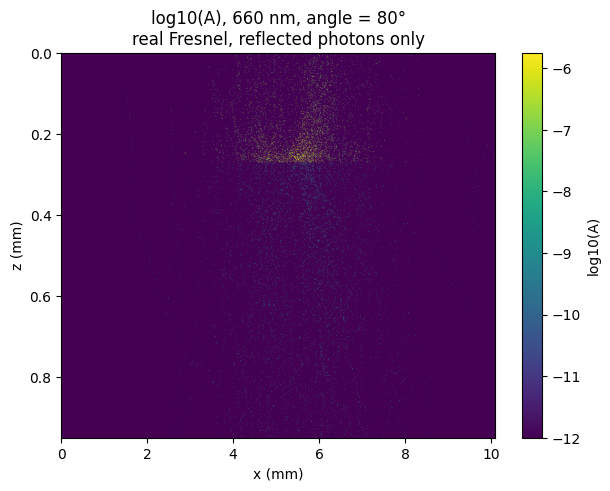

Stats:
  total_interface_hits: 31887
  total_reflections: 529
  total_reflected_photons: 488
  fraction_reflected_photons: 0.00976


In [14]:
A_real_reflected, stats_real_reflected = run_reflection_diagnostic(
    wl_test=660,
    theta_test=80,
    N_test=50000,
    refine_factor=10,
    force_reflection=False,
    reflected_only=True,
    stop_after_first_reflection=False,
    debug=False,
)

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_reflection_ballistic_after_bounce(
    mu_abs,
    mu_s,
    n,
    x_step_local,
    z_step_local,
    theta0_deg=80,
    N_photons=50000,
    refine_factor_label="",
):
    """
    Diagnostic only:
    - photon propagates normally before interface
    - at first interface hit, force reflection
    - after that, NO scattering
    - only reflected photons contribute

    Goal:
    make the reflected path visibly appear if the geometry is correct.
    """
    Wc = 0.01
    m = 10

    Nz, Nx = mu_abs.shape
    rng = np.random.default_rng()

    A = np.zeros_like(mu_abs, dtype=float)

    x_max_local = Nx * x_step_local
    theta0 = np.deg2rad(theta0_deg)

    reflected_photons = 0
    interface_hits = 0

    for p in range(N_photons):
        W = 1.0
        mu_x = np.sin(theta0)
        mu_z = np.cos(theta0)

        x = x_max_local / 2.0
        z = 0.0

        has_reflected = False

        while True:
            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                break

            s = -np.log(rng.uniform()) / mu_t

            # check interface crossing in z
            next_z = z + mu_z * s
            next_iz = int(next_z / z_step_local)

            if 0 <= next_iz < Nz:
                n1 = n[iz, ix]
                n2 = n[next_iz, ix]

                if n1 != n2:
                    interface_hits += 1

                    if not has_reflected:
                        # force first reflection
                        mu_z = -mu_z
                        has_reflected = True
                        reflected_photons += 1

            # propagate
            x += mu_x * s
            z += mu_z * s

            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                break

            deltaW = (mu_abs[iz, ix] / mu_t) * W
            W -= deltaW

            # only reflected photons contribute
            if has_reflected:
                A[iz, ix] += deltaW

            if W < Wc:
                if rng.uniform() <= 1 / m:
                    W *= m
                else:
                    break

            # IMPORTANT:
            # before reflection, keep normal scattering
            # after reflection, turn scattering OFF
            if not has_reflected:
                g = 0.9
                e3 = rng.uniform()

                cos_delta = (1 / (2 * g)) * (
                    1 + g**2 - ((1 - g**2) / (1 - g + 2 * g * e3))**2
                )
                cos_delta = np.clip(cos_delta, -1.0, 1.0)
                delta = np.arccos(cos_delta)

                if rng.uniform() < 0.5:
                    delta = -delta

                mu_x_new = mu_x * np.cos(delta) + mu_z * np.sin(delta)
                mu_z_new = -mu_x * np.sin(delta) + mu_z * np.cos(delta)

                norm = np.sqrt(mu_x_new**2 + mu_z_new**2)
                if norm > 0:
                    mu_x = mu_x_new / norm
                    mu_z = mu_z_new / norm
                else:
                    break

    A /= N_photons

    print("interface_hits =", interface_hits)
    print("reflected_photons =", reflected_photons)
    print("fraction reflected =", reflected_photons / N_photons)

    return A

interface_hits = 18509
reflected_photons = 18509
fraction reflected = 0.37018


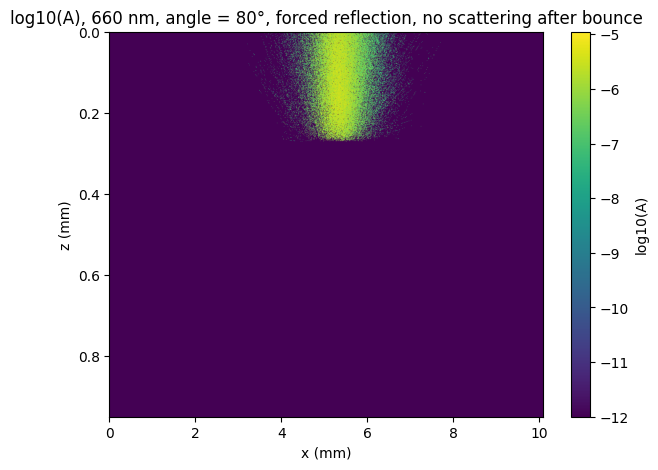

In [17]:
wl_test = 660
theta_test = 80
N_test = 50000

i_test = np.where(wavelength == wl_test)[0][0]

refine_factor = 10
mu_a_refined = np.repeat(mu_a[i_test], refine_factor, axis=1)
mu_s_refined = np.repeat(mu_s, refine_factor, axis=1)
n_refined = np.repeat(n, refine_factor, axis=1)

x_step_refined = x_step / refine_factor
z_step_local = z_step

A_ballistic_reflect = simulate_reflection_ballistic_after_bounce(
    mu_abs=mu_a_refined,
    mu_s=mu_s_refined,
    n=n_refined,
    x_step_local=x_step_refined,
    z_step_local=z_step_local,
    theta0_deg=theta_test,
    N_photons=N_test
)

plt.figure(figsize=(7,5))
plt.imshow(
    np.log10(A_ballistic_reflect + 1e-12),
    extent=[0, mu_a_refined.shape[1] * x_step_refined, mu_a_refined.shape[0] * z_step_local, 0],
    aspect='auto',
    cmap='viridis'
)
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.title(f"log10(A), {wl_test} nm, angle = {theta_test}°, forced reflection, no scattering after bounce")
plt.colorbar(label="log10(A)")
plt.show()

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_pure_ballistic_forced_reflection(
    mu_abs,
    mu_s,
    n,
    x_step_local,
    z_step_local,
    theta0_deg=80,
    N_photons=50000,
):
    """
    Strict geometry test:
    - no scattering before interface
    - force reflection at first interface
    - no scattering after
    - only reflected photons contribute

    This isolates whether the reflection path geometry is correct.
    """
    Wc = 0.01
    m = 10

    Nz, Nx = mu_abs.shape
    rng = np.random.default_rng()

    A = np.zeros_like(mu_abs, dtype=float)

    x_max_local = Nx * x_step_local
    theta0 = np.deg2rad(theta0_deg)

    reflected_photons = 0
    interface_hits = 0

    for p in range(N_photons):
        W = 1.0
        mu_x = np.sin(theta0)
        mu_z = np.cos(theta0)

        x = x_max_local / 2.0
        z = 0.0

        has_reflected = False

        while True:
            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                break

            s = -np.log(rng.uniform()) / mu_t

            # check interface crossing in z
            next_z = z + mu_z * s
            next_iz = int(next_z / z_step_local)

            if 0 <= next_iz < Nz:
                n1 = n[iz, ix]
                n2 = n[next_iz, ix]

                if n1 != n2 and not has_reflected:
                    interface_hits += 1

                    # force reflection
                    mu_z = -mu_z
                    has_reflected = True
                    reflected_photons += 1

            # propagate
            x += mu_x * s
            z += mu_z * s

            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                break

            deltaW = (mu_abs[iz, ix] / mu_t) * W
            W -= deltaW

            # only store reflected segment
            if has_reflected:
                A[iz, ix] += deltaW

            if W < Wc:
                if rng.uniform() <= 1 / m:
                    W *= m
                else:
                    break

            # IMPORTANT: no scattering anywhere in this diagnostic

    A /= N_photons

    print("interface_hits =", interface_hits)
    print("reflected_photons =", reflected_photons)
    print("fraction_reflected =", reflected_photons / N_photons)

    return A

interface_hits = 31146
reflected_photons = 31146
fraction_reflected = 0.62292


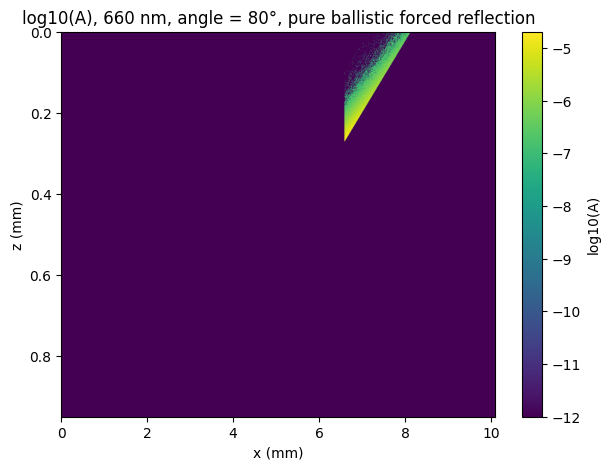

In [20]:
wl_test = 660
theta_test = 80
N_test = 50000

i_test = np.where(wavelength == wl_test)[0][0]

refine_factor = 10
mu_a_refined = np.repeat(mu_a[i_test], refine_factor, axis=1)
mu_s_refined = np.repeat(mu_s, refine_factor, axis=1)
n_refined = np.repeat(n, refine_factor, axis=1)

x_step_refined = x_step / refine_factor
z_step_local = z_step

A_ballistic_reflect = simulate_pure_ballistic_forced_reflection(
    mu_abs=mu_a_refined,
    mu_s=mu_s_refined,
    n=n_refined,
    x_step_local=x_step_refined,
    z_step_local=z_step_local,
    theta0_deg=theta_test,
    N_photons=N_test
)

plt.figure(figsize=(7,5))
plt.imshow(
    np.log10(A_ballistic_reflect + 1e-12),
    extent=[0, mu_a_refined.shape[1] * x_step_refined, mu_a_refined.shape[0] * z_step_local, 0],
    aspect='auto',
    cmap='viridis'
)
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.title(f"log10(A), {wl_test} nm, angle = {theta_test}°, pure ballistic forced reflection")
plt.colorbar(label="log10(A)")
plt.show()

wavelength = 660 nm
angle = 80 deg
N_photons = 2000
refine_factor = 10
interaction_scale = 1.0
x_step_refined = 0.01
z_step = 0.001
x_step_refined / z_step = 10.0
approx mu_t(original, top-center) = 22.838692 mm^-1
approx mu_t(scaled, top-center)   = 22.838692 mm^-1
approx mean free path = 0.043785 mm


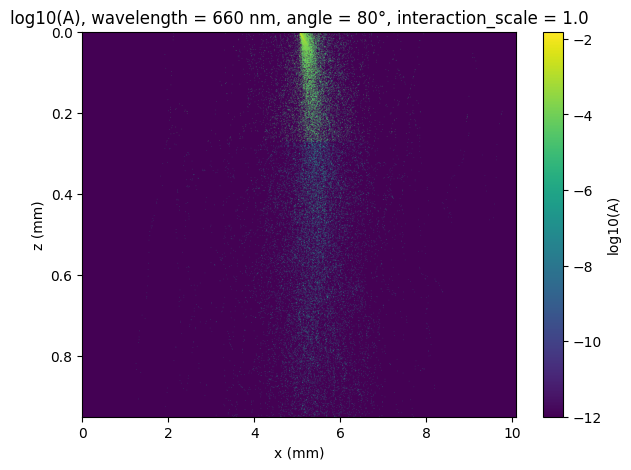

wavelength = 660 nm
angle = 80 deg
N_photons = 20000
refine_factor = 10
interaction_scale = 0.05
x_step_refined = 0.01
z_step = 0.001
x_step_refined / z_step = 10.0
approx mu_t(original, top-center) = 22.838692 mm^-1
approx mu_t(scaled, top-center)   = 1.141935 mm^-1
approx mean free path = 0.875707 mm


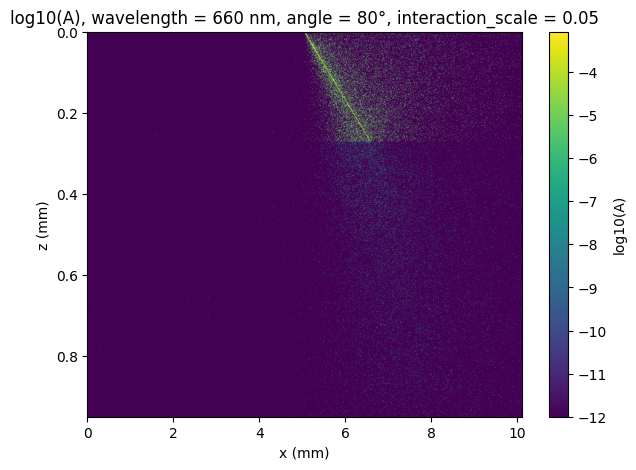

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Helper: refine x-grid to reduce staircase artifacts
# =========================================================
def refine_x_grid(field_2d, refine_factor=10):
    return np.repeat(field_2d, refine_factor, axis=1)


# =========================================================
# Main simulation
#
# Added controls:
#   - theta0_deg: launch angle from +z axis
#   - interaction_scale: multiplies BOTH mu_a and mu_s
#       interaction_scale = 1.0   -> original lab case
#       interaction_scale < 1.0   -> longer mean free path
#       interaction_scale > 1.0   -> shorter mean free path
#
# This stays close to your original lab logic.
# =========================================================
def simulate_light_propagation(
    mu_abs,
    mu_s,
    n,
    x_step_local,
    z_step_local,
    theta0_deg=0.0,
    N_photons=5000,
    interaction_scale=1.0,
    debug=False,
    max_debug_prints=30,
):
    g = 0.9
    Wc = 0.01
    m = 10

    Nz, Nx = mu_abs.shape
    rng = np.random.default_rng()

    # Scale both absorption and scattering so mu_t changes
    mu_abs_eff = interaction_scale * mu_abs
    mu_s_eff = interaction_scale * mu_s

    # initialize absorption map
    A = np.zeros_like(mu_abs_eff, dtype=float)

    # compute max coordinates
    x_max_local = Nx * x_step_local
    z_max_local = Nz * z_step_local

    # initial angle measured from +z axis
    theta0 = np.deg2rad(theta0_deg)

    debug_count = 0

    for p in range(N_photons):
        W = 1.0

        # initial launch direction
        mu_x = np.sin(theta0)
        mu_z = np.cos(theta0)

        x = x_max_local / 2.0
        z = 0.0

        while True:
            # current voxel
            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            # stop if outside
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # total interaction coefficient
            mu_t = mu_s_eff[iz, ix] + mu_abs_eff[iz, ix]
            if mu_t <= 0:
                break

            # step length
            s = -np.log(rng.uniform()) / mu_t

            # default if no interface crossed
            R = np.nan

            # -----------------------------------------
            # Fresnel reflection/transmission in z
            # -----------------------------------------
            next_z = z + mu_z * s
            next_iz = int(next_z / z_step_local)

            if 0 <= next_iz < Nz:
                n1 = n[iz, ix]
                n2 = n[next_iz, ix]

                if n1 != n2:
                    theta_i = np.arccos(np.clip(abs(mu_z), 0.0, 1.0))
                    sin_theta_t = (n1 / n2) * np.sin(theta_i)

                    if sin_theta_t > 1.0:
                        # total internal reflection
                        mu_z = -mu_z
                        R = 1.0
                    else:
                        theta_t = np.arcsin(sin_theta_t)

                        cos_theta_i = np.cos(theta_i)
                        cos_theta_t = np.cos(theta_t)

                        Rs = ((n1 * cos_theta_i - n2 * cos_theta_t) /
                              (n1 * cos_theta_i + n2 * cos_theta_t))**2
                        Rp = ((n1 * cos_theta_t - n2 * cos_theta_i) /
                              (n1 * cos_theta_t + n2 * cos_theta_i))**2
                        R = 0.5 * (Rs + Rp)

                        if rng.uniform() < R:
                            # reflection
                            mu_z = -mu_z
                        else:
                            # transmission
                            mu_z = np.sign(mu_z) * cos_theta_t

                            if np.sin(theta_i) >= 1e-12:
                                mu_x = mu_x * np.sin(theta_t) / np.sin(theta_i)

                            norm = np.sqrt(mu_x**2 + mu_z**2)
                            if norm > 0:
                                mu_x /= norm
                                mu_z /= norm

            # propagate photon
            x += mu_x * s
            z += mu_z * s

            # new voxel
            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            mu_t = mu_s_eff[iz, ix] + mu_abs_eff[iz, ix]
            if mu_t <= 0:
                break

            # absorption
            deltaW = (mu_abs_eff[iz, ix] / mu_t) * W
            W -= deltaW
            A[iz, ix] += deltaW

            # optional debug
            if debug and debug_count < max_debug_prints:
                print(
                    f"photon={p}, ix={ix}, iz={iz}, "
                    f"mu_x={mu_x:.6f}, mu_z={mu_z:.6f}, "
                    f"mu_t={mu_t:.6f}, R={R}"
                )
                debug_count += 1

            # Russian roulette
            if W < Wc:
                if rng.uniform() <= 1 / m:
                    W *= m
                else:
                    break

            # -----------------------------------------
            # 2D scattering relative to current direction
            # -----------------------------------------
            e3 = rng.uniform()

            cos_delta = (1 / (2 * g)) * (
                1 + g**2 - ((1 - g**2) / (1 - g + 2 * g * e3))**2
            )
            cos_delta = np.clip(cos_delta, -1.0, 1.0)

            delta = np.arccos(cos_delta)

            # random left/right deflection
            if rng.uniform() < 0.5:
                delta = -delta

            mu_x_new = mu_x * np.cos(delta) + mu_z * np.sin(delta)
            mu_z_new = -mu_x * np.sin(delta) + mu_z * np.cos(delta)

            norm = np.sqrt(mu_x_new**2 + mu_z_new**2)
            if norm > 0:
                mu_x = mu_x_new / norm
                mu_z = mu_z_new / norm
            else:
                break

    A /= N_photons
    return A


# =========================================================
# Runner
# Assumes these already exist in the notebook:
#   wavelength, mu_a, mu_s, n, x_step, z_step
# =========================================================
def run_angle_simulation(
    wl_test=660,
    theta_test=80,
    N_test=2000,
    refine_factor=10,
    interaction_scale=1.0,
    debug=False,
    max_debug_prints=30,
):
    i_test = np.where(wavelength == wl_test)[0][0]

    # refine x-grid only
    mu_a_refined = refine_x_grid(mu_a[i_test], refine_factor=refine_factor)
    mu_s_refined = refine_x_grid(mu_s, refine_factor=refine_factor)
    n_refined = refine_x_grid(n, refine_factor=refine_factor)

    x_step_refined = x_step / refine_factor
    z_step_local = z_step

    # print useful diagnostics
    mu_t_center_original = mu_a[i_test][0, mu_a[i_test].shape[1] // 2] + mu_s[0, mu_s.shape[1] // 2]
    mu_t_center_scaled = interaction_scale * mu_t_center_original

    print(f"wavelength = {wl_test} nm")
    print(f"angle = {theta_test} deg")
    print(f"N_photons = {N_test}")
    print(f"refine_factor = {refine_factor}")
    print(f"interaction_scale = {interaction_scale}")
    print(f"x_step_refined = {x_step_refined}")
    print(f"z_step = {z_step_local}")
    print(f"x_step_refined / z_step = {x_step_refined / z_step_local}")
    print(f"approx mu_t(original, top-center) = {mu_t_center_original:.6f} mm^-1")
    print(f"approx mu_t(scaled, top-center)   = {mu_t_center_scaled:.6f} mm^-1")
    if mu_t_center_scaled > 0:
        print(f"approx mean free path = {1.0 / mu_t_center_scaled:.6f} mm")

    A_test = simulate_light_propagation(
        mu_abs=mu_a_refined,
        mu_s=mu_s_refined,
        n=n_refined,
        x_step_local=x_step_refined,
        z_step_local=z_step_local,
        theta0_deg=theta_test,
        N_photons=N_test,
        interaction_scale=interaction_scale,
        debug=debug,
        max_debug_prints=max_debug_prints,
    )

    x_max_plot = mu_a_refined.shape[1] * x_step_refined
    z_max_plot = mu_a_refined.shape[0] * z_step_local

    plt.figure(figsize=(7, 5))
    plt.imshow(
        np.log10(A_test + 1e-12),
        extent=[0, x_max_plot, z_max_plot, 0],
        aspect='auto',
        cmap='viridis'
    )
    plt.xlabel("x (mm)")
    plt.ylabel("z (mm)")
    plt.title(
        f"log10(A), wavelength = {wl_test} nm, angle = {theta_test}°, "
        f"interaction_scale = {interaction_scale}"
    )
    plt.colorbar(label="log10(A)")
    plt.show()

    return A_test, x_step_refined, z_step_local


# =========================================================
# EXAMPLE RUN 1: real lab case
# =========================================================
A_real, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=660,
    theta_test=80,
    N_test=2000,
    refine_factor=10,
    interaction_scale=1.0,
    debug=False
)

# =========================================================
# EXAMPLE RUN 2: illustrative case with longer mean free path
# Try 0.05, 0.02, or 0.01
# =========================================================
A_idea, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=660,
    theta_test=80,
    N_test=20000,
    refine_factor=10,
    interaction_scale=0.05,
    debug=False
)

wavelength = 660 nm
angle = 80 deg
N_photons = 2000
refine_factor = 10
interaction_scale = 1.0
reflection_override = N
x_step_refined = 0.01
z_step = 0.001
x_step_refined / z_step = 10.0
approx mu_t(original, top-center) = 22.838692 mm^-1
approx mu_t(scaled, top-center)   = 22.838692 mm^-1
approx mean free path = 0.043785 mm


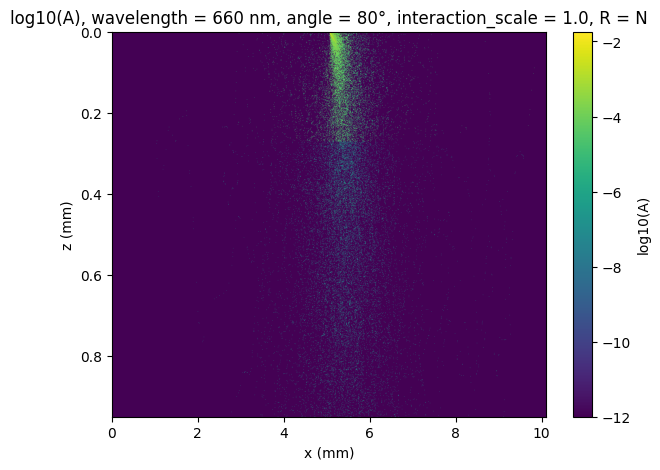

wavelength = 660 nm
angle = 80 deg
N_photons = 100000
refine_factor = 10
interaction_scale = 0.005
reflection_override = 0.9
x_step_refined = 0.01
z_step = 0.001
x_step_refined / z_step = 10.0
approx mu_t(original, top-center) = 22.838692 mm^-1
approx mu_t(scaled, top-center)   = 0.114193 mm^-1
approx mean free path = 8.757069 mm


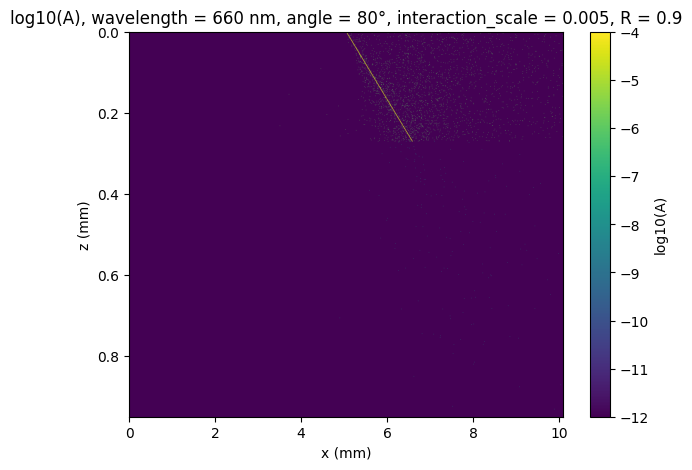

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Helper: refine x-grid to reduce staircase artifacts
# =========================================================
def refine_x_grid(field_2d, refine_factor=10):
    return np.repeat(field_2d, refine_factor, axis=1)


# =========================================================
# Main simulation
#
# Added controls:
#   - theta0_deg: launch angle from +z axis
#   - interaction_scale: multiplies BOTH mu_a and mu_s
#       interaction_scale = 1.0   -> original lab case
#       interaction_scale < 1.0   -> longer mean free path
#       interaction_scale > 1.0   -> shorter mean free path
#   - reflection_override:
#       "N" -> use normal Fresnel reflection
#       number between 0 and 1 -> force that reflection ratio
#
# This stays close to your original lab logic.
# =========================================================
def simulate_light_propagation(
    mu_abs,
    mu_s,
    n,
    x_step_local,
    z_step_local,
    theta0_deg=0.0,
    N_photons=5000,
    interaction_scale=1.0,
    reflection_override="N",
    debug=False,
    max_debug_prints=30,
):
    g = 0.9
    Wc = 0.01
    m = 10

    Nz, Nx = mu_abs.shape
    rng = np.random.default_rng()

    # Scale both absorption and scattering so mu_t changes
    mu_abs_eff = interaction_scale * mu_abs
    mu_s_eff = interaction_scale * mu_s

    # initialize absorption map
    A = np.zeros_like(mu_abs_eff, dtype=float)

    # compute max coordinates
    x_max_local = Nx * x_step_local
    z_max_local = Nz * z_step_local

    # initial angle measured from +z axis
    theta0 = np.deg2rad(theta0_deg)

    debug_count = 0

    for p in range(N_photons):
        W = 1.0

        # initial launch direction
        mu_x = np.sin(theta0)
        mu_z = np.cos(theta0)

        x = x_max_local / 2.0
        z = 0.0

        while True:
            # current voxel
            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            # stop if outside
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # total interaction coefficient
            mu_t = mu_s_eff[iz, ix] + mu_abs_eff[iz, ix]
            if mu_t <= 0:
                break

            # step length
            s = -np.log(rng.uniform()) / mu_t

            # default if no interface crossed
            R = np.nan

            # -----------------------------------------
            # Fresnel reflection/transmission in z
            # -----------------------------------------
            next_z = z + mu_z * s
            next_iz = int(next_z / z_step_local)

            if 0 <= next_iz < Nz:
                n1 = n[iz, ix]
                n2 = n[next_iz, ix]

                if n1 != n2:
                    theta_i = np.arccos(np.clip(abs(mu_z), 0.0, 1.0))
                    sin_theta_t = (n1 / n2) * np.sin(theta_i)

                    if sin_theta_t > 1.0:
                        # total internal reflection
                        mu_z = -mu_z
                        R = 1.0
                    else:
                        theta_t = np.arcsin(sin_theta_t)

                        # -------------------------------
                        # Use normal Fresnel OR override
                        # -------------------------------
                        if reflection_override == "N":
                            cos_theta_i = np.cos(theta_i)
                            cos_theta_t = np.cos(theta_t)

                            Rs = ((n1 * cos_theta_i - n2 * cos_theta_t) /
                                  (n1 * cos_theta_i + n2 * cos_theta_t))**2
                            Rp = ((n1 * cos_theta_t - n2 * cos_theta_i) /
                                  (n1 * cos_theta_t + n2 * cos_theta_i))**2
                            R = 0.5 * (Rs + Rp)
                        else:
                            R = float(reflection_override)
                            R = np.clip(R, 0.0, 1.0)

                        if rng.uniform() < R:
                            # reflection
                            mu_z = -mu_z
                        else:
                            # transmission
                            mu_z = np.sign(mu_z) * np.cos(theta_t)

                            if np.sin(theta_i) >= 1e-12:
                                mu_x = mu_x * np.sin(theta_t) / np.sin(theta_i)

                            norm = np.sqrt(mu_x**2 + mu_z**2)
                            if norm > 0:
                                mu_x /= norm
                                mu_z /= norm

            # propagate photon
            x += mu_x * s
            z += mu_z * s

            # new voxel
            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            mu_t = mu_s_eff[iz, ix] + mu_abs_eff[iz, ix]
            if mu_t <= 0:
                break

            # absorption
            deltaW = (mu_abs_eff[iz, ix] / mu_t) * W
            W -= deltaW
            A[iz, ix] += deltaW

            # optional debug
            if debug and debug_count < max_debug_prints:
                print(
                    f"photon={p}, ix={ix}, iz={iz}, "
                    f"mu_x={mu_x:.6f}, mu_z={mu_z:.6f}, "
                    f"mu_t={mu_t:.6f}, R={R}"
                )
                debug_count += 1

            # Russian roulette
            if W < Wc:
                if rng.uniform() <= 1 / m:
                    W *= m
                else:
                    break

            # -----------------------------------------
            # 2D scattering relative to current direction
            # -----------------------------------------
            e3 = rng.uniform()

            cos_delta = (1 / (2 * g)) * (
                1 + g**2 - ((1 - g**2) / (1 - g + 2 * g * e3))**2
            )
            cos_delta = np.clip(cos_delta, -1.0, 1.0)

            delta = np.arccos(cos_delta)

            # random left/right deflection
            if rng.uniform() < 0.5:
                delta = -delta

            mu_x_new = mu_x * np.cos(delta) + mu_z * np.sin(delta)
            mu_z_new = -mu_x * np.sin(delta) + mu_z * np.cos(delta)

            norm = np.sqrt(mu_x_new**2 + mu_z_new**2)
            if norm > 0:
                mu_x = mu_x_new / norm
                mu_z = mu_z_new / norm
            else:
                break

    A /= N_photons
    return A


# =========================================================
# Runner
# Assumes these already exist in the notebook:
#   wavelength, mu_a, mu_s, n, x_step, z_step
# =========================================================
def run_angle_simulation(
    wl_test=660,
    theta_test=80,
    N_test=2000,
    refine_factor=10,
    interaction_scale=1.0,
    reflection_override="N",
    debug=False,
    max_debug_prints=30,
):
    i_test = np.where(wavelength == wl_test)[0][0]

    # refine x-grid only
    mu_a_refined = refine_x_grid(mu_a[i_test], refine_factor=refine_factor)
    mu_s_refined = refine_x_grid(mu_s, refine_factor=refine_factor)
    n_refined = refine_x_grid(n, refine_factor=refine_factor)

    x_step_refined = x_step / refine_factor
    z_step_local = z_step

    # print useful diagnostics
    mu_t_center_original = mu_a[i_test][0, mu_a[i_test].shape[1] // 2] + mu_s[0, mu_s.shape[1] // 2]
    mu_t_center_scaled = interaction_scale * mu_t_center_original

    print(f"wavelength = {wl_test} nm")
    print(f"angle = {theta_test} deg")
    print(f"N_photons = {N_test}")
    print(f"refine_factor = {refine_factor}")
    print(f"interaction_scale = {interaction_scale}")
    print(f"reflection_override = {reflection_override}")
    print(f"x_step_refined = {x_step_refined}")
    print(f"z_step = {z_step_local}")
    print(f"x_step_refined / z_step = {x_step_refined / z_step_local}")
    print(f"approx mu_t(original, top-center) = {mu_t_center_original:.6f} mm^-1")
    print(f"approx mu_t(scaled, top-center)   = {mu_t_center_scaled:.6f} mm^-1")
    if mu_t_center_scaled > 0:
        print(f"approx mean free path = {1.0 / mu_t_center_scaled:.6f} mm")

    A_test = simulate_light_propagation(
        mu_abs=mu_a_refined,
        mu_s=mu_s_refined,
        n=n_refined,
        x_step_local=x_step_refined,
        z_step_local=z_step_local,
        theta0_deg=theta_test,
        N_photons=N_test,
        interaction_scale=interaction_scale,
        reflection_override=reflection_override,
        debug=debug,
        max_debug_prints=max_debug_prints,
    )

    x_max_plot = mu_a_refined.shape[1] * x_step_refined
    z_max_plot = mu_a_refined.shape[0] * z_step_local

    plt.figure(figsize=(7, 5))
    plt.imshow(
        np.log10(A_test + 1e-12),
        extent=[0, x_max_plot, z_max_plot, 0],
        aspect='auto',
        cmap='viridis'
    )
    plt.xlabel("x (mm)")
    plt.ylabel("z (mm)")
    plt.title(
        f"log10(A), wavelength = {wl_test} nm, angle = {theta_test}°, "
        f"interaction_scale = {interaction_scale}, R = {reflection_override}"
    )
    plt.colorbar(label="log10(A)")
    plt.show()

    return A_test, x_step_refined, z_step_local


# =========================================================
# EXAMPLE RUN 1: regular Fresnel
# =========================================================
A_real, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=660,
    theta_test=80,
    N_test=2000,
    refine_factor=10,
    interaction_scale=1.0,
    reflection_override="N",
    debug=False
)

# =========================================================
# EXAMPLE RUN 2: forced 50:50 reflection
# =========================================================
A_half, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=660,
    theta_test=80,
    N_test=100000,
    refine_factor=10,
    interaction_scale=0.005,
    reflection_override=0.9,
    debug=False
)




wavelength = 660 nm
angle = 80 deg
N_photons = 100000
refine_factor = 10
interaction_scale = 0.05
reflection_override = 0.2
approx mu_t(scaled, top-center) = 1.141935 mm^-1
approx mean free path = 0.875707 mm


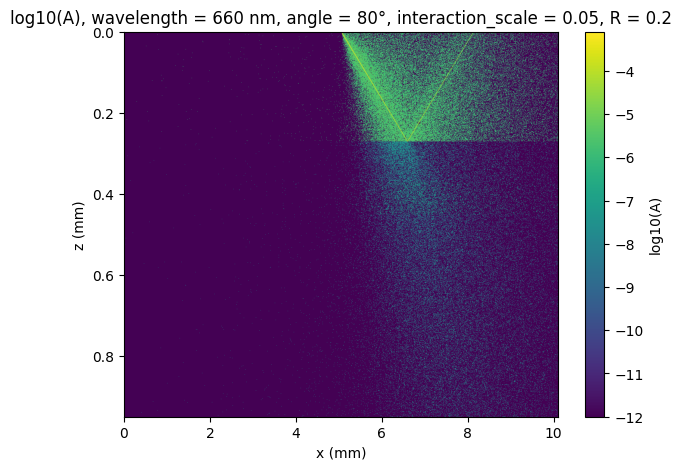

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Helper: refine x-grid to reduce staircase artifacts
# =========================================================
def refine_x_grid(field_2d, refine_factor=10):
    return np.repeat(field_2d, refine_factor, axis=1)


# =========================================================
# Main simulation with CORRECT interface crossing:
# - propagate to interface
# - reflect/transmit
# - propagate remaining step
# =========================================================
def simulate_light_propagation(
    mu_abs,
    mu_s,
    n,
    x_step_local,
    z_step_local,
    theta0_deg=0.0,
    N_photons=5000,
    interaction_scale=1.0,
    reflection_override="N",
    debug=False,
    max_debug_prints=30,
):
    g = 0.9
    Wc = 0.01
    m = 10

    Nz, Nx = mu_abs.shape
    rng = np.random.default_rng()

    mu_abs_eff = interaction_scale * mu_abs
    mu_s_eff = interaction_scale * mu_s

    A = np.zeros_like(mu_abs_eff, dtype=float)

    x_max_local = Nx * x_step_local
    theta0 = np.deg2rad(theta0_deg)

    # Find horizontal interface depths from refractive index profile
    n_profile = n[:, 0]
    interface_rows = np.where(np.diff(n_profile) != 0)[0] + 1
    interface_zs = interface_rows * z_step_local

    debug_count = 0

    for p in range(N_photons):
        W = 1.0

        mu_x = np.sin(theta0)
        mu_z = np.cos(theta0)

        x = x_max_local / 2.0
        z = 0.0

        while True:
            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            mu_t = mu_s_eff[iz, ix] + mu_abs_eff[iz, ix]
            if mu_t <= 0:
                break

            s = -np.log(rng.uniform()) / mu_t
            R = np.nan

            x_old = x
            z_old = z
            next_z = z + mu_z * s

            crossed_interface = False

            if mu_z > 0:
                candidates = interface_zs[(interface_zs > z_old) & (interface_zs <= next_z)]
                if len(candidates) > 0:
                    z_int = candidates[0]
                    crossed_interface = True
            elif mu_z < 0:
                candidates = interface_zs[(interface_zs < z_old) & (interface_zs >= next_z)]
                if len(candidates) > 0:
                    z_int = candidates[-1]
                    crossed_interface = True

            if crossed_interface:
                # propagate to interface first
                s_to_int = (z_int - z) / mu_z
                s_rem = s - s_to_int

                x = x + mu_x * s_to_int
                z = z_int

                ix_int = int(x / x_step_local)
                if ix_int < 0 or ix_int >= Nx:
                    break

                # identify refractive indices across interface
                if mu_z > 0:
                    iz_above = max(int((z_int - 1e-12) / z_step_local), 0)
                    iz_below = min(int((z_int + 1e-12) / z_step_local), Nz - 1)
                    n1 = n[iz_above, ix_int]
                    n2 = n[iz_below, ix_int]
                else:
                    iz_below = min(int((z_int + 1e-12) / z_step_local), Nz - 1)
                    iz_above = max(int((z_int - 1e-12) / z_step_local), 0)
                    n1 = n[iz_below, ix_int]
                    n2 = n[iz_above, ix_int]

                theta_i = np.arccos(np.clip(abs(mu_z), 0.0, 1.0))
                sin_theta_t = (n1 / n2) * np.sin(theta_i)

                if sin_theta_t > 1.0:
                    # total internal reflection
                    mu_z = -mu_z
                    R = 1.0
                else:
                    theta_t = np.arcsin(sin_theta_t)

                    if reflection_override == "N":
                        cos_theta_i = np.cos(theta_i)
                        cos_theta_t = np.cos(theta_t)

                        Rs = ((n1 * cos_theta_i - n2 * cos_theta_t) /
                              (n1 * cos_theta_i + n2 * cos_theta_t))**2
                        Rp = ((n1 * cos_theta_t - n2 * cos_theta_i) /
                              (n1 * cos_theta_t + n2 * cos_theta_i))**2
                        R = 0.5 * (Rs + Rp)
                    else:
                        R = float(reflection_override)
                        R = np.clip(R, 0.0, 1.0)

                    if rng.uniform() < R:
                        # reflection
                        mu_z = -mu_z
                    else:
                        # transmission
                        mu_z = np.sign(mu_z) * np.cos(theta_t)

                        if np.sin(theta_i) >= 1e-12:
                            mu_x = mu_x * np.sin(theta_t) / np.sin(theta_i)

                        norm = np.sqrt(mu_x**2 + mu_z**2)
                        if norm > 0:
                            mu_x /= norm
                            mu_z /= norm

                # propagate remaining segment after bounce/transmission
                x = x + mu_x * s_rem
                z = z + mu_z * s_rem

            else:
                # no interface crossed: simple propagation
                x = x + mu_x * s
                z = z + mu_z * s

            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            mu_t = mu_s_eff[iz, ix] + mu_abs_eff[iz, ix]
            if mu_t <= 0:
                break

            deltaW = (mu_abs_eff[iz, ix] / mu_t) * W
            W -= deltaW
            A[iz, ix] += deltaW

            if debug and debug_count < max_debug_prints:
                print(
                    f"photon={p}, ix={ix}, iz={iz}, "
                    f"mu_x={mu_x:.6f}, mu_z={mu_z:.6f}, "
                    f"mu_t={mu_t:.6f}, R={R}, crossed_interface={crossed_interface}"
                )
                debug_count += 1

            if W < Wc:
                if rng.uniform() <= 1 / m:
                    W *= m
                else:
                    break

            # scattering
            e3 = rng.uniform()
            cos_delta = (1 / (2 * g)) * (
                1 + g**2 - ((1 - g**2) / (1 - g + 2 * g * e3))**2
            )
            cos_delta = np.clip(cos_delta, -1.0, 1.0)

            delta = np.arccos(cos_delta)
            if rng.uniform() < 0.5:
                delta = -delta

            mu_x_new = mu_x * np.cos(delta) + mu_z * np.sin(delta)
            mu_z_new = -mu_x * np.sin(delta) + mu_z * np.cos(delta)

            norm = np.sqrt(mu_x_new**2 + mu_z_new**2)
            if norm > 0:
                mu_x = mu_x_new / norm
                mu_z = mu_z_new / norm
            else:
                break

    A /= N_photons
    return A


# =========================================================
# Runner
# =========================================================
def run_angle_simulation(
    wl_test=660,
    theta_test=80,
    N_test=2000,
    refine_factor=10,
    interaction_scale=1.0,
    reflection_override="N",
    debug=False,
    max_debug_prints=30,
):
    if wl_test not in [660, 940]:
        raise ValueError("wl_test must be 660 or 940")

    i_test = np.where(wavelength == wl_test)[0][0]

    mu_a_refined = refine_x_grid(mu_a[i_test], refine_factor=refine_factor)
    mu_s_refined = refine_x_grid(mu_s, refine_factor=refine_factor)
    n_refined = refine_x_grid(n, refine_factor=refine_factor)

    x_step_refined = x_step / refine_factor
    z_step_local = z_step

    mu_t_center_original = mu_a[i_test][0, mu_a[i_test].shape[1] // 2] + mu_s[0, mu_s.shape[1] // 2]
    mu_t_center_scaled = interaction_scale * mu_t_center_original

    print(f"wavelength = {wl_test} nm")
    print(f"angle = {theta_test} deg")
    print(f"N_photons = {N_test}")
    print(f"refine_factor = {refine_factor}")
    print(f"interaction_scale = {interaction_scale}")
    print(f"reflection_override = {reflection_override}")
    print(f"approx mu_t(scaled, top-center) = {mu_t_center_scaled:.6f} mm^-1")
    if mu_t_center_scaled > 0:
        print(f"approx mean free path = {1.0 / mu_t_center_scaled:.6f} mm")

    A_test = simulate_light_propagation(
        mu_abs=mu_a_refined,
        mu_s=mu_s_refined,
        n=n_refined,
        x_step_local=x_step_refined,
        z_step_local=z_step_local,
        theta0_deg=theta_test,
        N_photons=N_test,
        interaction_scale=interaction_scale,
        reflection_override=reflection_override,
        debug=debug,
        max_debug_prints=max_debug_prints,
    )

    x_max_plot = mu_a_refined.shape[1] * x_step_refined
    z_max_plot = mu_a_refined.shape[0] * z_step_local

    plt.figure(figsize=(7, 5))
    plt.imshow(
        np.log10(A_test + 1e-12),
        extent=[0, x_max_plot, z_max_plot, 0],
        aspect='auto',
        cmap='viridis'
    )
    plt.xlabel("x (mm)")
    plt.ylabel("z (mm)")
    plt.title(
        f"log10(A), wavelength = {wl_test} nm, angle = {theta_test}°, "
        f"interaction_scale = {interaction_scale}, R = {reflection_override}"
    )
    plt.colorbar(label="log10(A)")
    plt.show()

    return A_test, x_step_refined, z_step_local


A_half, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=660,
    theta_test=80,
    N_test=100000,
    refine_factor=10,
    interaction_scale=0.05,
    reflection_override=0.2,
    debug=False
)

wavelength = 660 nm
angle = 0 deg
N_photons = 100000
refine_factor = 10
interaction_scale = 1
reflection_override = N
approx mu_t(scaled, top-center) = 22.838692 mm^-1
approx mean free path = 0.043785 mm


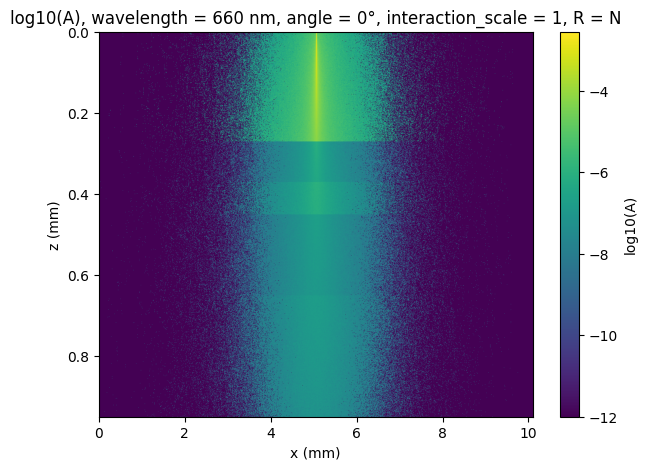

In [49]:
A_half, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=660,
    theta_test=0,
    N_test=100000,
    refine_factor=10,
    interaction_scale=1,
    reflection_override= "N",
    debug=False
)